# Student Performance Analytics & Prediction

## Notebook 5: Decision Tree

### Objective

Train a Decision Tree Regressor to predict students' final grades (G3) and compare its performance with Linear Regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor

In [14]:
df = pd.read_csv("../data/student-por.csv")
x=df.drop("G3",axis=1)
y=df["G3"]

X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)
categorical_cols=X_train.select_dtypes(include="object").columns.tolist()
numerical_cols=X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor=ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols),("num",StandardScaler(),numerical_cols)])


C:\Users\Krish\AppData\Local\Temp\ipykernel_27288\3979720509.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=X_train.select_dtypes(include="object").columns.tolist()


In [ ]:
model=Pipeline([("preprocessor",preprocessor),("regressor",DecisionTreeRegressor(random_state=42))])
model.fit(X_train,y_train)

In [34]:
y_pred=model.predict(X_test)
prediction_df = pd.DataFrame({"Actual": y_test.values,"Predicted": y_pred.round(2)})
prediction_df.head(10)

,Actual,Predicted
0,19,18.0
1,12,11.0
2,18,17.0
3,11,11.0
4,11,11.0
5,17,16.0
6,18,18.0
7,8,10.0
8,10,11.0
9,11,11.0


In [18]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=mse**0.5
r2=r2_score(y_test,y_pred)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,2))

MAE : 0.82
MSE : 2.5
RMSE: 1.58
R2 Score: 0.74


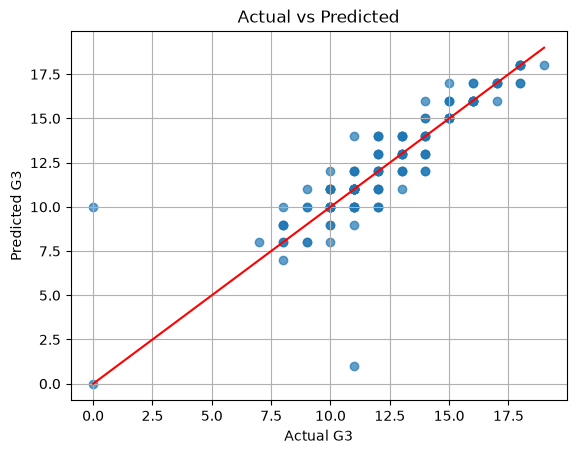

In [29]:
plt.Figure(figsize=(6,6))
plt.scatter(y_test,y_pred,alpha=0.7)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted")

plt.grid()
plt.show()

### Observation

- Most predicted values are close to the actual values
- Some predictions are farther from the diagonal line
- Most predictions lie close to the diagonal line, indicating good prediction accuracy
### Insight

- Predictions near the diagonal indicate good model performance
- Larger deviations represent prediction errors

### Possible Action

- Improve the model by trying more advanced algorithms
- Compare this model with Random Forest

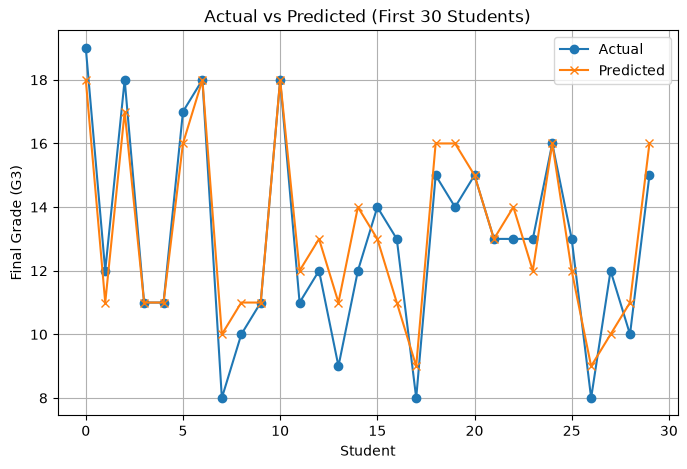

In [32]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values[:30], label="Actual", marker="o")
plt.plot(y_pred[:30], label="Predicted", marker="x")

plt.title("Actual vs Predicted (First 30 Students)")
plt.xlabel("Student")
plt.ylabel("Final Grade (G3)")

plt.legend()
plt.grid() 
plt.show()

## Final Conclusion

- The Decision Tree model successfully predicted students' final grades
- The model achieved an R² score of 0.74, explaining about 74% of the variation in G3
- Prediction errors are reasonably low, although the model is slightly less accurate than Linear Regression
- This model will be compared with Random Forest in the next notebook